In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [39]:
#Load the dataset 'IPL'.
IPL = pd.read_csv("IPL_Dataset(2008-2024).csv")
IPL

,Match_ID,Date,Teams,Venue,Toss_Winner,Toss_Decision,Match_Winner,Win_Type,Win_Margin,First_Innings_Score,Second_Innings_Score,Player_of_Match,Umpire,Umpire1,Umpire2,Powerplay_Scores,Middle_Overs_Scores,Death_Overs_Scores
0,335982,2008-04-18,Royal Challengers Bangalore vs Kolkata Knight ...,M Chinnaswamy Stadium,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,222,82.0,BB McCullum,Asad Rauf,RE Koertzen,J Srinath,61,97,64
1,335983,2008-04-19,Kings XI Punjab vs Chennai Super Kings,"Punjab Cricket Association Stadium, Mohali",Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,240,207.0,MEK Hussey,MR Benson,SL Shastri,S Venkataraghavan,53,116,71
2,335984,2008-04-19,Delhi Daredevils vs Rajasthan Royals,Feroz Shah Kotla,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,129,132.0,MF Maharoof,Aleem Dar,GA Pratapkumar,GR Viswanath,40,66,23
3,335985,2008-04-20,Mumbai Indians vs Royal Challengers Bangalore,Wankhede Stadium,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,165,166.0,MV Boucher,SJ Davis,DJ Harper,J Srinath,47,71,47
4,335986,2008-04-20,Kolkata Knight Riders vs Deccan Chargers,Eden Gardens,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,110,112.0,DJ Hussey,BF Bowden,K Hariharan,FM Engineer,39,43,28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1068,1426283,2024-04-28,Gujarat Titans vs Royal Challengers Bengaluru,"Narendra Modi Stadium, Ahmedabad",Royal Challengers Bengaluru,field,Royal Challengers Bengaluru,wickets,9.0,200,206.0,WG Jacks,Nitin Menon,VK Sharma,J Srinath,42,106,52
1069,1426284,2024-04-28,Chennai Super Kings vs Sunrisers Hyderabad,"MA Chidambaram Stadium, Chepauk, Chennai",Sunrisers Hyderabad,field,Chennai Super Kings,runs,78.0,212,134.0,RD Gaikwad,R Pandit,MV Saidharshan Kumar,Sanjay Verma,50,109,53
1070,1426285,2024-04-29,Delhi Capitals vs Kolkata Knight Riders,"Eden Gardens, Kolkata",Delhi Capitals,bat,Kolkata Knight Riders,wickets,7.0,153,157.0,CV Varun,Navdeep Singh,Tapan Sharma,V Narayan Kutty,67,61,25
1071,1426286,2024-04-30,Mumbai Indians vs Lucknow Super Giants,Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...,Lucknow Super Giants,field,Lucknow Super Giants,wickets,4.0,144,145.0,MP Stoinis,MA Gough,UV Gandhe,DS Manohar,28,78,38


In [40]:
IPL.shape

(1073, 18)

In [41]:
IPL.size

19314

In [42]:
IPL.columns

Index(['Match_ID', 'Date', 'Teams', 'Venue', 'Toss_Winner', 'Toss_Decision',
       'Match_Winner', 'Win_Type', 'Win_Margin', 'First_Innings_Score',
       'Second_Innings_Score', 'Player_of_Match', 'Umpire', 'Umpire1',
       'Umpire2', 'Powerplay_Scores', 'Middle_Overs_Scores',
       'Death_Overs_Scores'],
      dtype='object')

In [43]:
IPL.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1073 entries, 0 to 1072
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Match_ID              1073 non-null   int64  
 1   Date                  1073 non-null   object 
 2   Teams                 1073 non-null   object 
 3   Venue                 1073 non-null   object 
 4   Toss_Winner           1073 non-null   object 
 5   Toss_Decision         1073 non-null   object 
 6   Match_Winner          1073 non-null   object 
 7   Win_Type              1054 non-null   object 
 8   Win_Margin            1054 non-null   float64
 9   First_Innings_Score   1073 non-null   int64  
 10  Second_Innings_Score  1070 non-null   float64
 11  Player_of_Match       1068 non-null   object 
 12  Umpire                1073 non-null   object 
 13  Umpire1               1073 non-null   object 
 14  Umpire2               1073 non-null   object 
 15  Powerplay_Scores     

In [44]:
#Converting the dtype of 'Date' column.
IPL["Date"] = pd.to_datetime(IPL["Date"])

In [45]:
#Creating a column 'Year' from the column 'Date'.
IPL["Year"] = IPL["Date"].dt.year

In [46]:
#Checking the null values.
IPL.isnull().sum

<bound method DataFrame.sum of       Match_ID   Date  Teams  Venue  Toss_Winner  Toss_Decision  Match_Winner  \
0        False  False  False  False        False          False         False   
1        False  False  False  False        False          False         False   
2        False  False  False  False        False          False         False   
3        False  False  False  False        False          False         False   
4        False  False  False  False        False          False         False   
...        ...    ...    ...    ...          ...            ...           ...   
1068     False  False  False  False        False          False         False   
1069     False  False  False  False        False          False         False   
1070     False  False  False  False        False          False         False   
1071     False  False  False  False        False          False         False   
1072     False  False  False  False        False          False         False 

In [47]:
##Checking the % of the total null values in the dataset
Missing_values = IPL.isnull().mean() * 100
Missing_values

Match_ID                0.000000
Date                    0.000000
Teams                   0.000000
Venue                   0.000000
Toss_Winner             0.000000
Toss_Decision           0.000000
Match_Winner            0.000000
Win_Type                1.770736
Win_Margin              1.770736
First_Innings_Score     0.000000
Second_Innings_Score    0.279590
Player_of_Match         0.465983
Umpire                  0.000000
Umpire1                 0.000000
Umpire2                 0.000000
Powerplay_Scores        0.000000
Middle_Overs_Scores     0.000000
Death_Overs_Scores      0.000000
Year                    0.000000
dtype: float64

In [48]:
IPL['Win_Type'].unique()

array(['runs', 'wickets', nan], dtype=object)

In [49]:
IPL['Win_Type'].value_counts()

Win_Type
wickets    569
runs       485
Name: count, dtype: int64

In [50]:
##Filling the null values in the win_Type column with 'No Result'.
IPL['Win_Type'].fillna("No Result",inplace = True)

In [51]:
##Filling the null values in the Win_Margin column with 0
IPL['Win_Margin'].fillna(0,inplace = True)

In [52]:
##Dropping the rows of the null values of Second_Innings_Score.
IPL.dropna(subset = ["Second_Innings_Score"],inplace = True)

In [53]:
##Filling the null values in the Player_of_match with 'NoPlayer'.
IPL['Player_of_Match'].fillna("No Player",inplace = True)

In [54]:
##Checking if my dataset contains any null values.
IPL.duplicated().sum()

np.int64(0)

## Outliers

<Axes: >

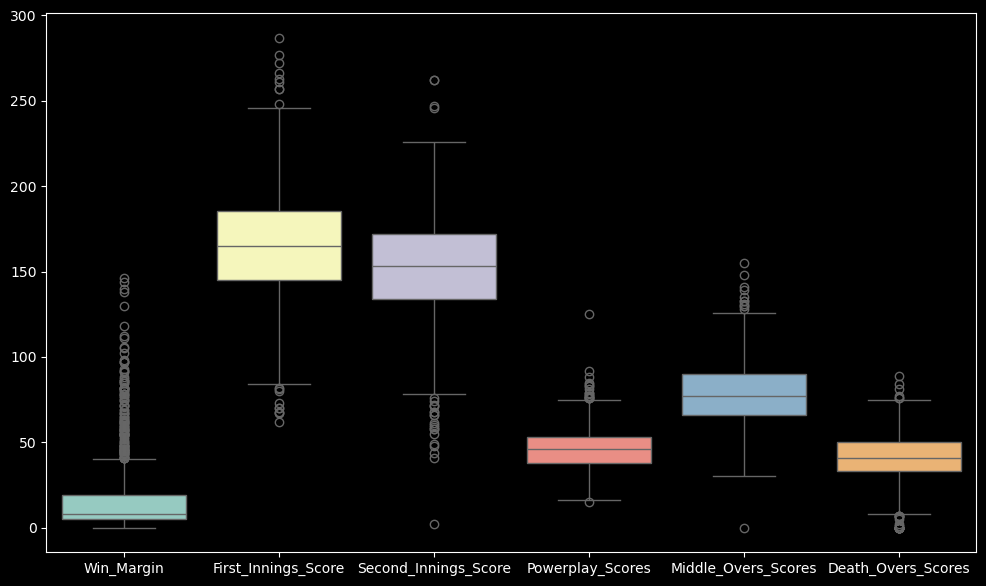

In [55]:
plt.figure(figsize = (12,7))
sns.boxplot(IPL[['Win_Margin','First_Innings_Score','Second_Innings_Score','Powerplay_Scores','Middle_Overs_Scores','Death_Overs_Scores']])

## Univariate Analysis

#### Histogram to get frequency for total match winnings by each team.

In [56]:
#Changing the name of the team
IPL.loc[IPL['Match_Winner'] == 'Royal Challengers Bengaluru', 'Match_Winner'] = 'Royal Challengers Bangalore'
IPL.loc[IPL['Match_Winner'] == 'Rising Pune Supergiant', 'Match_Winner'] = 'Rising Pune Supergiants'

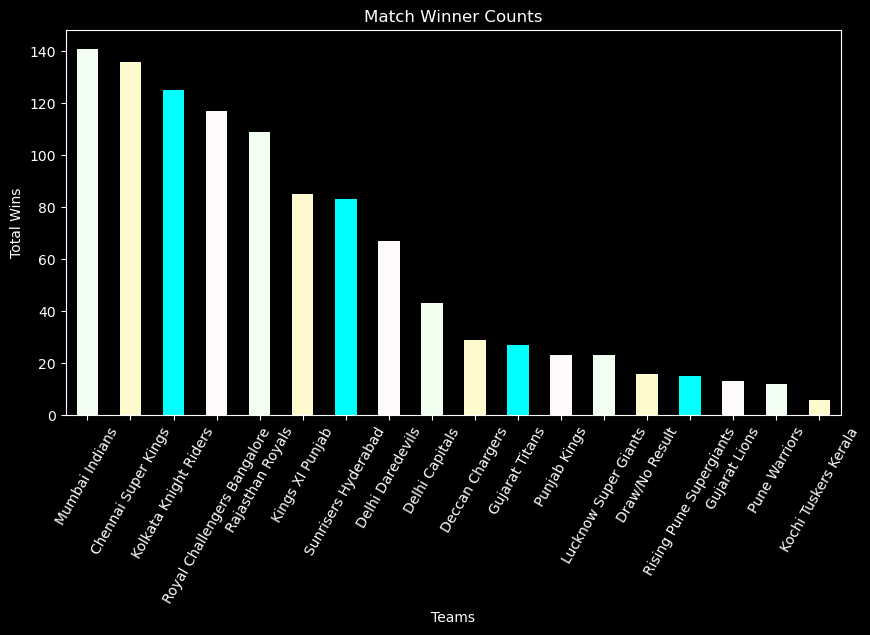

In [57]:
#plotting a histogram for total match winnings by each team
# Plotting a histogram for total match winnings by each team.
winning = IPL['Match_Winner'].value_counts()
plt.style.use('dark_background')
plt.figure(figsize = (10,5))
c = IPL['Match_Winner'].nunique()
colors = ['honeydew','lemonchiffon','cyan','snow']
winning.plot(kind = 'bar',color = colors)
plt.title('Match Winner Counts')
plt.xlabel('Teams')
plt.ylabel('Total Wins')
plt.xticks(rotation = 60)
plt.show()

### Piechart to get distribution of IPL Match Wins by Teams (2008-2024)

<Axes: ylabel='count'>

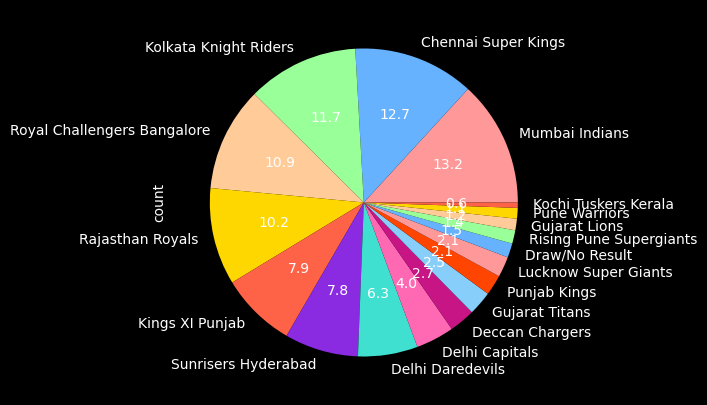

In [58]:
plt.figure(figsize = (10,5))
colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99', '#FFD700', '#FF6347',
          '#8A2BE2', '#40E0D0', '#FF69B4', '#C71585', '#87CEFA', '#FF4500']
winning.plot(kind = 'pie',autopct = '%.1f',colors = colors)

### Histplot(kde) to get the Distribution and Frequency of First and Second Innings Scores.

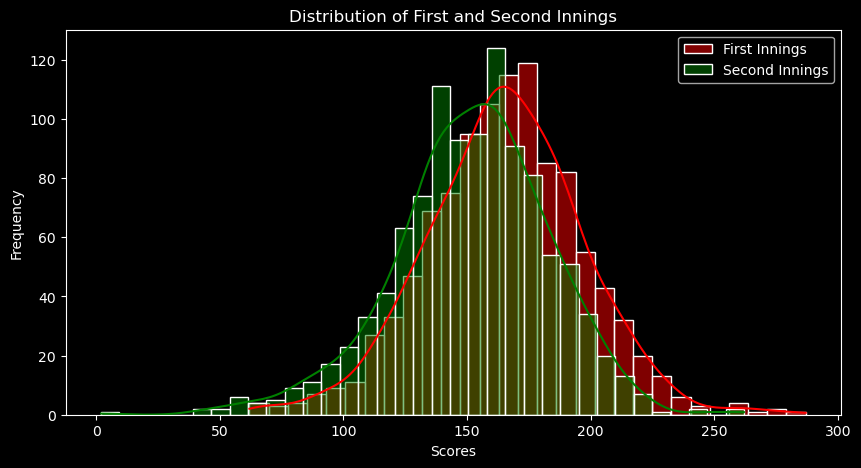

In [59]:
plt.style.use("dark_background")
plt.figure(figsize = (10,5))
sns.histplot(IPL["First_Innings_Score"],kde = True,color = 'red',label = 'First Innings')
sns.histplot(IPL["Second_Innings_Score"],kde = True,color = 'green',label = 'Second Innings')
plt.title("Distribution of First and Second Innings")
plt.xlabel('Scores')
plt.ylabel('Frequency')
plt.legend()
plt.show()

### Bar chart to find how many matches played in each venue

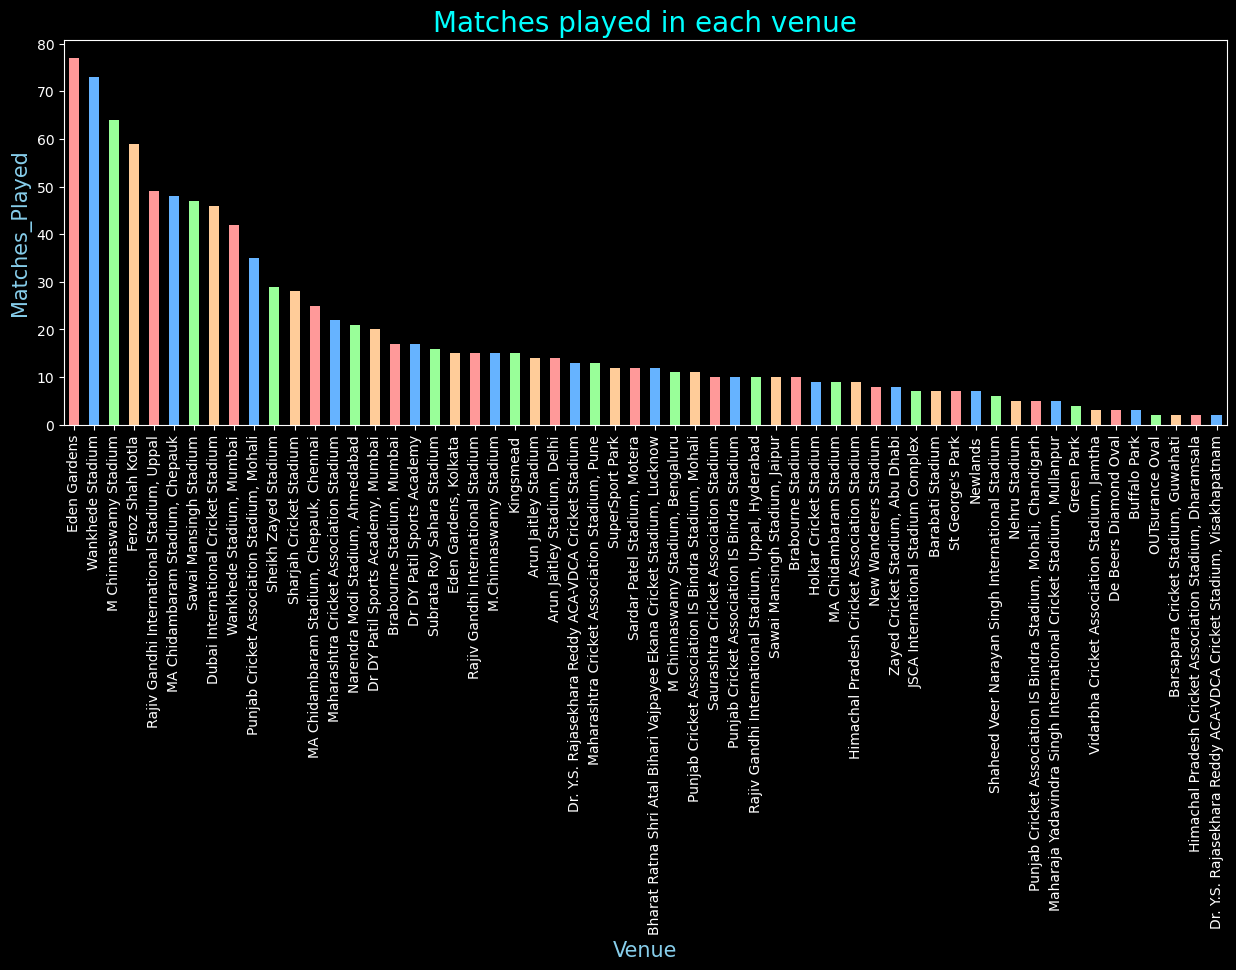

In [60]:
Match_Venue = IPL["Venue"].value_counts()
plt.style.use("dark_background")
plt.figure(figsize = (15,5))
plt.style.use('seaborn-v0_8-dark-palette')
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99']
Match_Venue.plot(kind = 'bar',color = colors)
plt.title("Matches played in each venue",size = 20,color = 'cyan')  
plt.xlabel('Venue', size = 15, color = 'skyblue')
plt.ylabel('Matches_Played', size = 15, color = 'skyblue')
plt.xticks(rotation = 90)
plt.show()

### Histogram Subplots for Powerplay_Scores,Middle_Overs_Scores

Text(0, 0.5, 'Frequency')

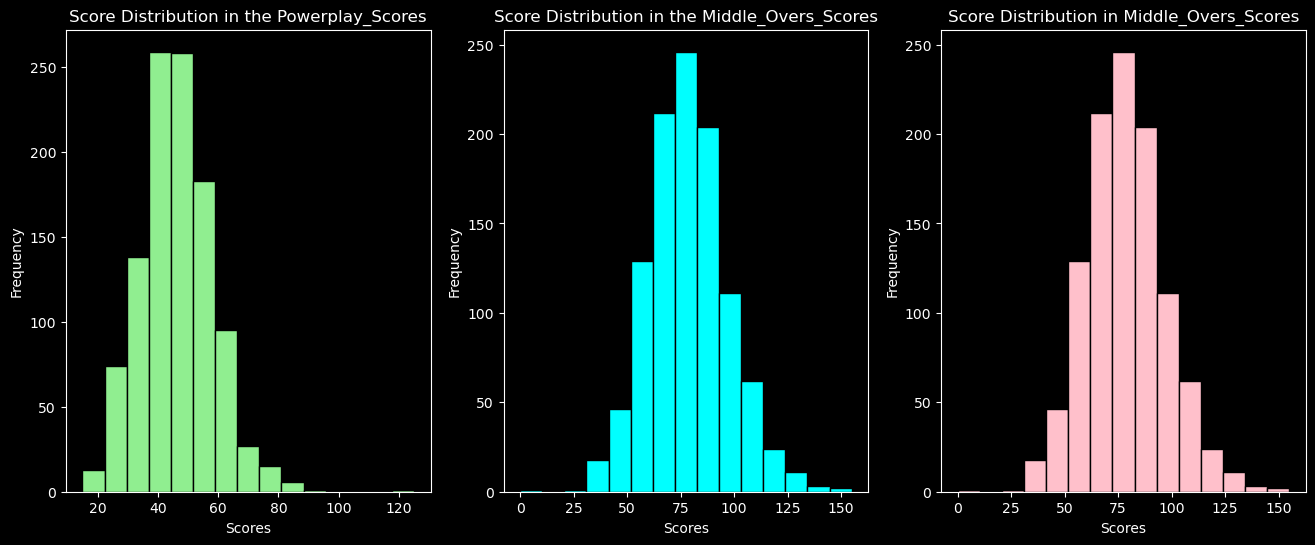

In [61]:
plt.figure(figsize=(16,6))
plt.subplot(1,3,1)
plt.hist(IPL["Powerplay_Scores"], bins = 15, color = 'lightgreen',edgecolor = 'black')
plt.title("Score Distribution in the Powerplay_Scores")
plt.xlabel("Scores")
plt.ylabel("Frequency")
plt.subplot(1,3,2)
plt.hist(IPL["Middle_Overs_Scores"], bins = 15, color = 'cyan', edgecolor = 'black')
plt.title("Score Distribution in the Middle_Overs_Scores")
plt.xlabel('Scores')
plt.ylabel('Frequency')
plt.subplot(1,3,3)
plt.hist(IPL["Middle_Overs_Scores"], bins = 15, color = 'pink', edgecolor = 'black')
plt.title("Score Distribution in Middle_Overs_Scores")
plt.xlabel("Scores")
plt.ylabel("Frequency")

### Countplot for Umpiring Statistics.

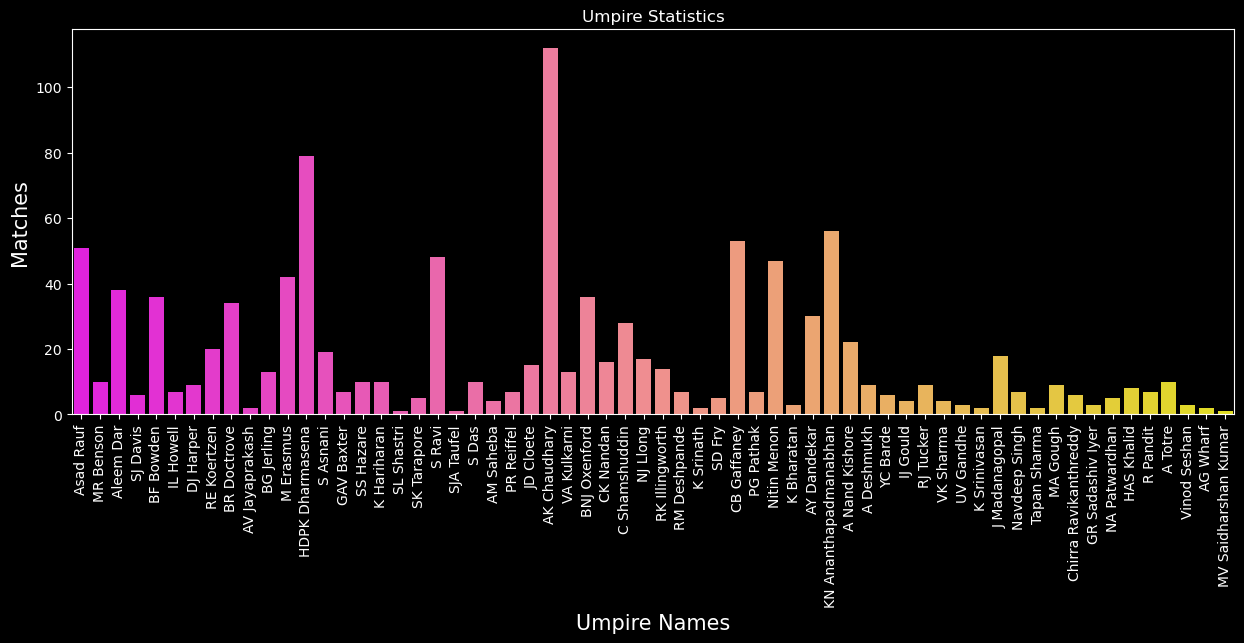

In [62]:
plt.style.use("dark_background")
plt.figure(figsize = (15,5))
sns.countplot(data = IPL, 
                x  = 'Umpire',
                palette = 'spring')
plt.title("Umpire Statistics")
plt.xlabel("Umpire Names",size = 15)
plt.ylabel("Matches",size = 15)
plt.xticks(rotation = 90)
plt.show()

### Bar chart to get the top 10 players who have won most M.O.M awards.

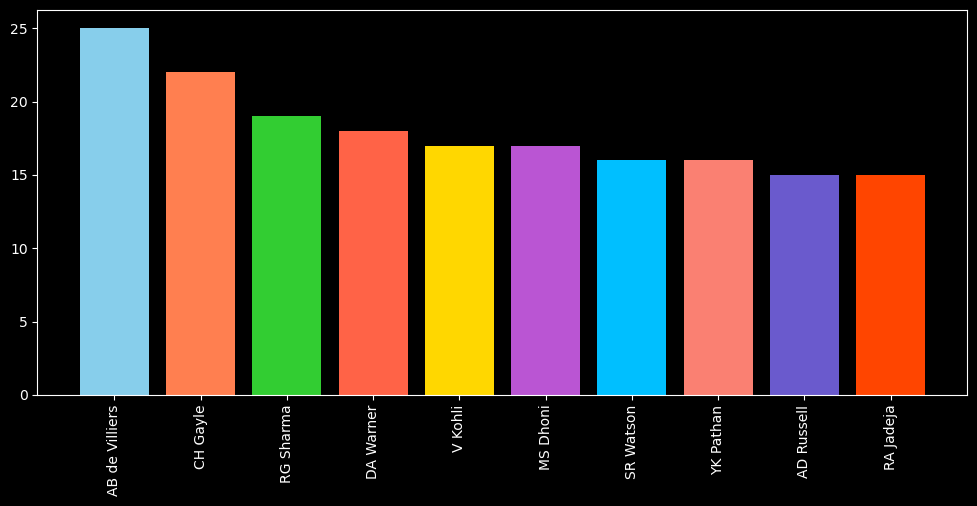

In [63]:
plt.figure(figsize = (12,5))
plt.style.use('dark_background')
c = ['#87CEEB', '#FF7F50', '#32CD32','#FF6347', '#FFD700', '#BA55D3', '#00BFFF','#FA8072', '#6A5ACD', '#FF4500']
plt.bar(IPL["Player_of_Match"].value_counts()[0:10].keys(), IPL["Player_of_Match"].value_counts()[0:10], color = c)
plt.xticks(rotation =90)
plt.show()

# Bivariate Analysis

### Which team has won more tosses and chooses what.

In [64]:
IPL.loc[IPL['Toss_Decision'] == 'Royal Challengers Bengaluru','Toss_Decision'] = 'Royal Challengers Bangalore'
IPL.loc[IPL['Toss_Decision'] == 'Rising Pune Supergiant','Toss_Decision'] = 'Rising Pune Supergiants'
IPL.loc[IPL['Toss_Winner'] == 'Royal Challengers Bengaluru','Toss_Winner'] = 'Royal Challengers Bangalore'
IPL.loc[IPL['Toss_Winner'] == 'Rising Pune Supergiant','Toss_Winner'] = 'Rising Pune Supergiants'

In [65]:
Total_Toss_Winner = IPL['Toss_Winner'].value_counts()
Total_Toss_Winner

Toss_Winner
Mumbai Indians                 139
Kolkata Knight Riders          122
Royal Challengers Bangalore    120
Chennai Super Kings            119
Rajasthan Royals               114
Kings XI Punjab                 85
Sunrisers Hyderabad             85
Delhi Daredevils                79
Delhi Capitals                  49
Deccan Chargers                 43
Gujarat Titans                  22
Punjab Kings                    21
Pune Warriors                   20
Lucknow Super Giants            16
Gujarat Lions                   15
Rising Pune Supergiants         13
Kochi Tuskers Kerala             8
Name: count, dtype: int64

### Stacked bar plot to get Toss Decision by Team after Winning Toss.

In [66]:
x = pd.crosstab(IPL['Toss_Winner'],IPL['Toss_Decision'])

<Figure size 1000x1000 with 0 Axes>

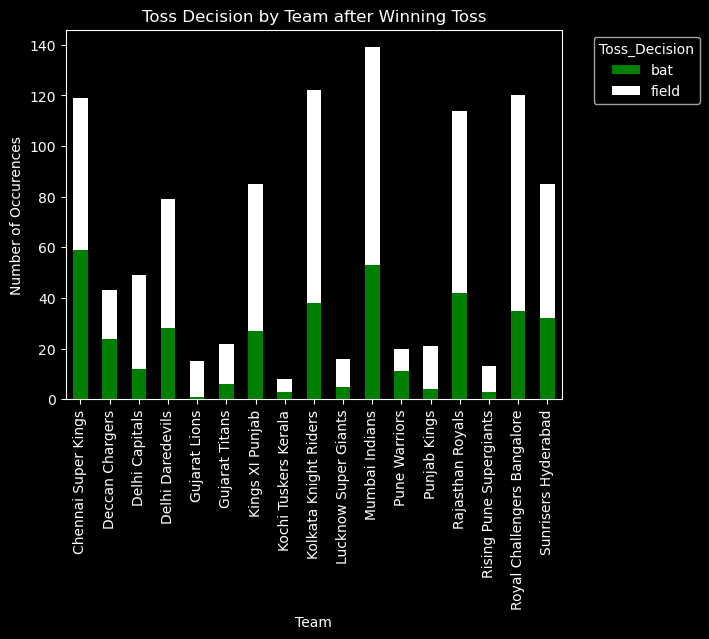

In [67]:
plt.figure(figsize = (10,10))  #Increased the size of plot
x.plot(kind = 'bar', stacked = True, cmap = 'ocean')
plt.title ("Toss Decision by Team after Winning Toss")
plt.xlabel('Team')
plt.ylabel('Number of Occurences')
plt.legend(title = 'Toss_Decision', bbox_to_anchor = (1.05,1))
plt.show()

In [68]:
IPL['Player_of_Match'].value_counts().head()

Player_of_Match
AB de Villiers    25
CH Gayle          22
RG Sharma         19
DA Warner         18
V Kohli           17
Name: count, dtype: int64

In [69]:
IPL.head(3)

,Match_ID,Date,Teams,Venue,Toss_Winner,Toss_Decision,Match_Winner,Win_Type,Win_Margin,First_Innings_Score,Second_Innings_Score,Player_of_Match,Umpire,Umpire1,Umpire2,Powerplay_Scores,Middle_Overs_Scores,Death_Overs_Scores,Year
0,335982,2008-04-18,Royal Challengers Bangalore vs Kolkata Knight ...,M Chinnaswamy Stadium,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,222,82.0,BB McCullum,Asad Rauf,RE Koertzen,J Srinath,61,97,64,2008
1,335983,2008-04-19,Kings XI Punjab vs Chennai Super Kings,"Punjab Cricket Association Stadium, Mohali",Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,240,207.0,MEK Hussey,MR Benson,SL Shastri,S Venkataraghavan,53,116,71,2008
2,335984,2008-04-19,Delhi Daredevils vs Rajasthan Royals,Feroz Shah Kotla,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,129,132.0,MF Maharoof,Aleem Dar,GA Pratapkumar,GR Viswanath,40,66,23,2008


### Pie Chart to get the Proportion of Wins by teams after Batting First.

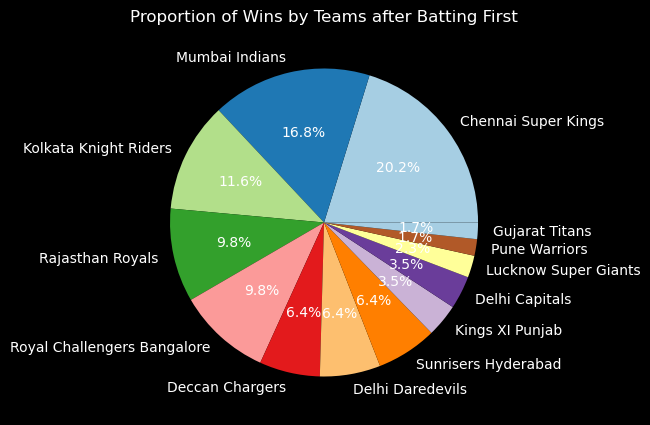

In [70]:
IPL['Bat_First'] = np.where(IPL['Toss_Decision'] == 'bat', IPL['Toss_Winner'], 'Other Team')
bat_first_wins = IPL[IPL['Bat_First'] == IPL['Match_Winner']]
team_wins_bat_first = bat_first_wins['Match_Winner'].value_counts()
plt.figure(figsize = (10,5))
team_wins_bat_first.plot(kind = 'pie', autopct = '%1.1f%%', colors=plt.cm.Paired.colors)
plt.title('Proportion of Wins by Teams after Batting First')
plt.ylabel('')
plt.show()

### Pie Chart to get the Proportion of Wins by Teams after Bowling.

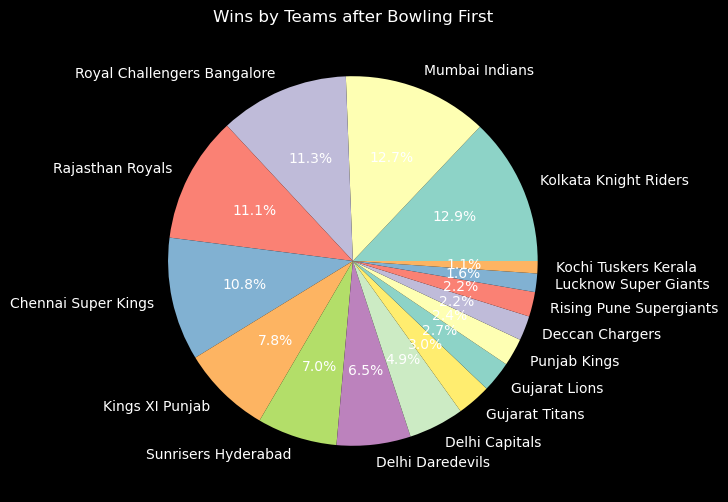

In [71]:
IPL['Bowl_First'] = np.where(IPL['Toss_Decision'] == 'field', IPL['Toss_Winner'],'Other Team')
bowl_first_wins = IPL[IPL['Bowl_First'] == IPL['Match_Winner']]
team_wins_bowl_first = bowl_first_wins['Match_Winner'].value_counts()
plt.figure(figsize=(12,6))
team_wins_bowl_first.plot(kind='pie', autopct='%1.1f%%', color=plt.cm.Paired.colors)
plt.title('Wins by Teams after Bowling First')
plt.ylabel("")
plt.show()                     

### Countplot to find the Toss Decision depeding on the Venue.

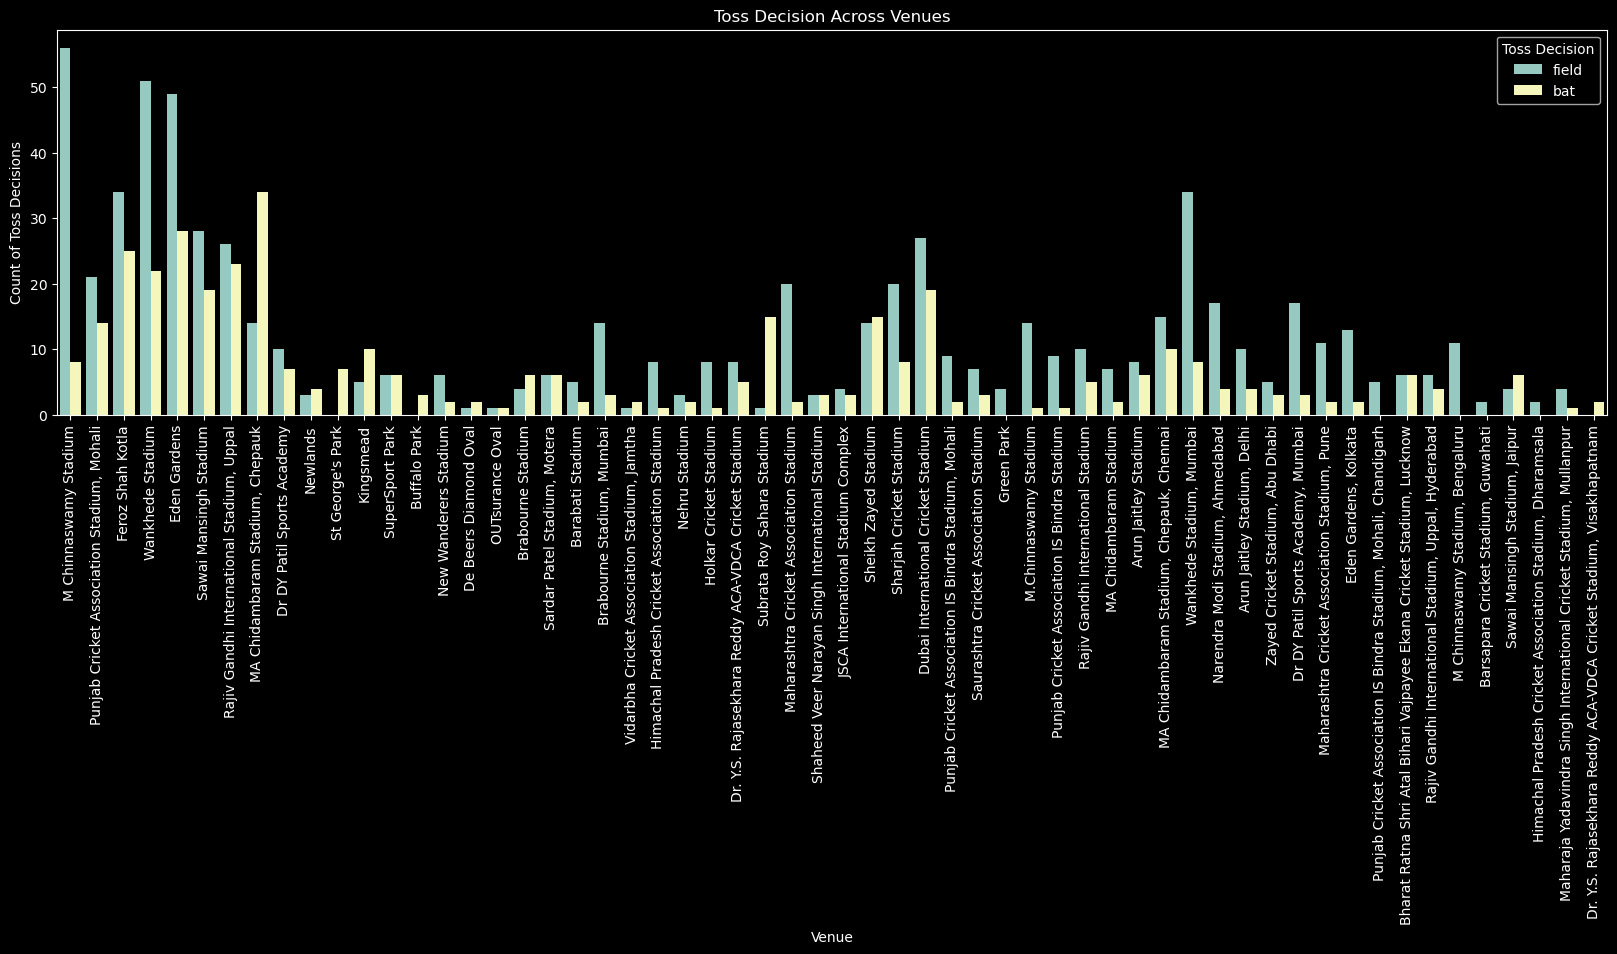

In [72]:
# Multivariate Analysis 1: Toss Decision, Venue, and Match Outcome
plt.figure(figsize=(20, 5))
sns.countplot(IPL, x="Venue", hue="Toss_Decision")
plt.title("Toss Decision Across Venues")
plt.xlabel("Venue")
plt.ylabel("Count of Toss Decisions")
plt.xticks(rotation=90)
plt.legend(title="Toss Decision")
plt.show()

In [73]:
avg_scores = IPL.groupby("Year")[["First_Innings_Score", "Second_Innings_Score"]].mean().reset_index()
avg_scores

,Year,First_Innings_Score,Second_Innings_Score
0,2008,160.965517,148.293103
1,2009,150.263158,136.052632
2,2010,164.783333,149.616667
3,2011,153.708333,139.319444
4,2012,157.540541,145.878378
5,2013,155.894737,140.697368
6,2014,163.066667,152.083333
7,2015,165.672414,146.948276
8,2016,162.600000,151.766667
9,2017,165.779661,152.338983


### Line Plot of Average First and Second Innings Scores Over the Years

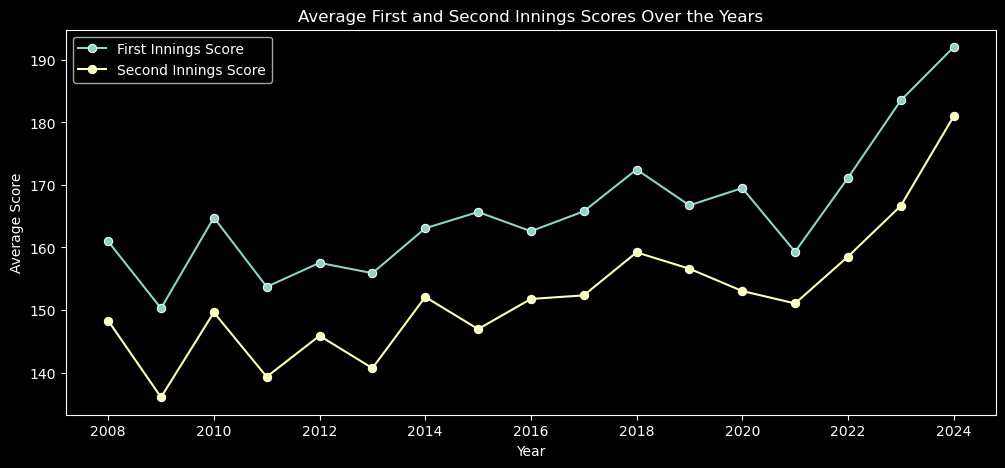

In [74]:
#Calculate average scores per year
plt.figure(figsize=(12, 5))
sns.lineplot(data=avg_scores, x="Year", y="First_Innings_Score", label="First Innings Score", marker="o")
sns.lineplot(data=avg_scores, x="Year", y="Second_Innings_Score", label="Second Innings Score", marker="o")
plt.title("Average First and Second Innings Scores Over the Years")
plt.xlabel("Year")
plt.ylabel("Average Score")
plt.legend()
plt.show()

# <font color = 'green'> Multivariate Analysis </font>


### Heatmap for finding the correlation between first_Innings_score, Second_Innings_Score, Powerplay_scores, middle_over_score, death_over_scores, win_margin

<Axes: >

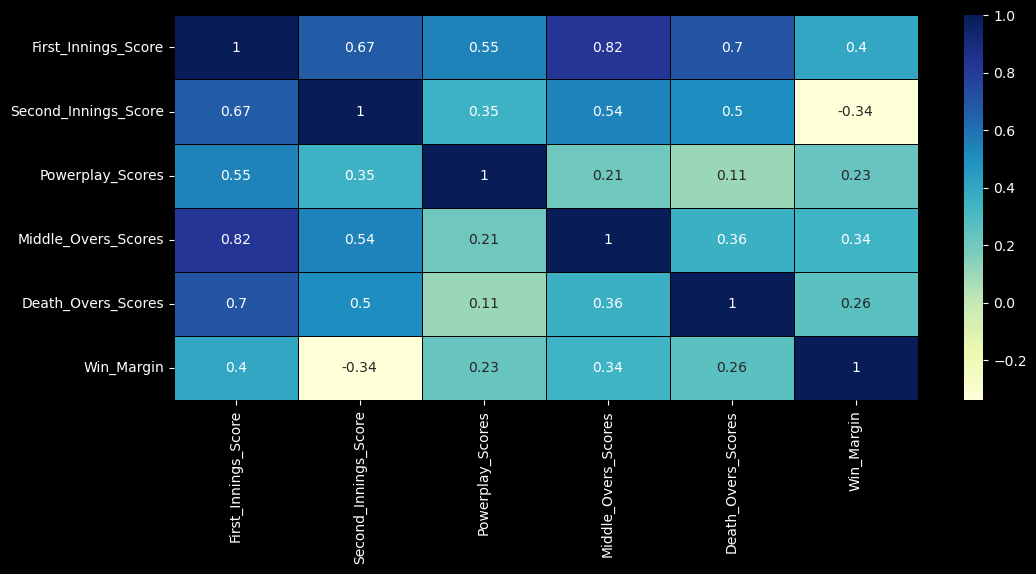

In [75]:
plt.figure(figsize = (12,5))
plt.style.use('dark_background')
a = IPL[['First_Innings_Score', 'Second_Innings_Score', 'Powerplay_Scores', 'Middle_Overs_Scores', 'Death_Overs_Scores', 'Win_Margin']]
sns.heatmap(a.corr(), annot=True, cmap='YlGnBu', linewidths=0.5, linecolor='black')

In [76]:
avg_scores = IPL.groupby('Year')[['Powerplay_Scores', 'Middle_Overs_Scores', 'Death_Overs_Scores']].mean()
avg_scores

,Powerplay_Scores,Middle_Overs_Scores,Death_Overs_Scores
Year,,,
2008,44.879310,76.706897,39.379310
2009,44.035088,69.210526,37.017544
2010,47.000000,75.716667,42.066667
2011,42.000000,76.125000,35.583333
2012,42.729730,75.797297,39.013514
2013,41.026316,73.421053,41.447368
2014,44.300000,79.533333,39.233333
2015,46.931034,78.224138,40.517241
2016,43.866667,79.250000,39.483333


### Line Plot of Powerplay_scores, Middle_over_scores, Death_over_scores over years.

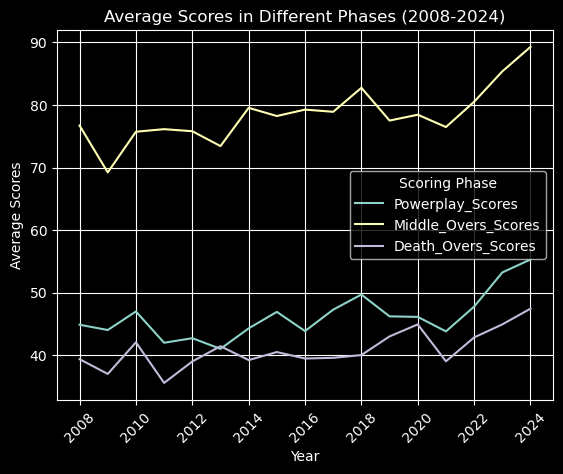

In [77]:
avg_scores = IPL.groupby('Year')[['Powerplay_Scores', 'Middle_Overs_Scores', 'Death_Overs_Scores']].mean()
avg_scores.plot()
plt.title('Average Scores in Different Phases (2008-2024)')
plt.xlabel('Year')
plt.ylabel('Average Scores')
plt.xticks(rotation=45)
plt.grid()
# plt.ylim(10, None)
plt.legend(title='Scoring Phase')
plt.show()